# LSTM PPO Portfolio Model Training

Train PPO with LSTM policy to capture temporal dependencies in sparse features.

**Why LSTM?**
- Captures temporal patterns (momentum, mean reversion, regime changes)
- Aggregates sparse features over time into meaningful representations
- Hidden state carries forward relevant historical information

**Architecture:**
- RecurrentPPO from sb3-contrib
- MlpLstmPolicy with shared LSTM for actor/critic
- PortfolioEnv2 (holdings-based)

## 1. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Check if sb3-contrib is installed
try:
    from sb3_contrib import RecurrentPPO
    print("sb3-contrib imported successfully")
except ImportError:
    print("ERROR: sb3-contrib not installed!")
    print("Install with: pip install sb3-contrib")
    raise

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import config and RL system
from config import *
from rl_system import (
    load_data,
    PortfolioEnv2,
    PortfolioMonitor,
    TrainingLogger,
    create_walk_forward_folds,
    print_fold_summary,
    EqualWeight,
    BuyHold,
    RiskParity,
    Momentum,
    MinVariance,
    backtest_baseline
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"\nSetup complete")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Using PortfolioEnv2 (holdings-based) with LSTM PPO")

sb3-contrib imported successfully

Setup complete
Timestamp: 2025-11-20 07:28:51
Using PortfolioEnv2 (holdings-based) with LSTM PPO


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Configuration

In [2]:
print("="*80)
print("LSTM PPO TRAINING CONFIGURATION")
print("="*80)

print(f"\nData:")
print(f"  Tickers: {len(TICKERS)} - {', '.join(TICKERS)}")
print(f"  Features: {len(FEATURE_COLS)}")

print(f"\nEnvironment:")
print(f"  Reward: log_return")
print(f"  Rebalance: {REBALANCE_FREQUENCY} weeks")
print(f"  Transaction cost: {TRANSACTION_COST*10000:.0f} bps")

print(f"\nLSTM Architecture:")
print(f"  Hidden size: {LSTM_HIDDEN_SIZE}")
print(f"  Layers: {N_LSTM_LAYERS}")
print(f"  Shared LSTM: {SHARED_LSTM}")
print(f"  Critic LSTM: {ENABLE_CRITIC_LSTM}")

print(f"\nTraining:")
print(f"  Timesteps: {TOTAL_TIMESTEPS:,}")
print(f"  Learning rate: {LSTM_LEARNING_RATE}")
print(f"  N steps: {LSTM_N_STEPS}")
print(f"  Batch size: {LSTM_BATCH_SIZE}")
print(f"  N epochs: {LSTM_N_EPOCHS}")
print(f"  Early stop patience: {EARLY_STOP_PATIENCE}")

print("="*80)

LSTM PPO TRAINING CONFIGURATION

Data:
  Tickers: 7 - NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Features: 100

Environment:
  Reward: log_return
  Rebalance: 4 weeks
  Transaction cost: 25 bps

LSTM Architecture:
  Hidden size: 100
  Layers: 1
  Shared LSTM: True
  Critic LSTM: False

Training:
  Timesteps: 100,000
  Learning rate: 0.0001
  N steps: 128
  Batch size: 64
  N epochs: 5
  Early stop patience: 5


def train_lstm_ppo_fold(fold_idx, train_data, val_data):
    """Train LSTM PPO model on one fold with early stopping."""
    
    print(f"\n{'='*80}")
    print(f"LSTM PPO | FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*80}")
    
    # Data info
    train_periods = len(train_data[DATE_COL].unique())
    val_periods = len(val_data[DATE_COL].unique())
    train_start = train_data[DATE_COL].min().strftime('%Y-%m-%d')
    train_end = train_data[DATE_COL].max().strftime('%Y-%m-%d')
    val_start = val_data[DATE_COL].min().strftime('%Y-%m-%d')
    val_end = val_data[DATE_COL].max().strftime('%Y-%m-%d')
    
    print(f"\nData:")
    print(f"   Train: {train_start} to {train_end} ({train_periods} periods)")
    print(f"   Val:   {val_start} to {val_end} ({val_periods} periods)")
    
    # Create environments using PortfolioEnv2
    def make_train_env():
        env = PortfolioEnv2(
            data=train_data.copy(),
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type='log_return',
            seed=RANDOM_SEED + fold_idx,
            annualization_factor=ANNUALIZATION_FACTOR,
            risk_free_rate=RISK_FREE_RATE
        )
        return PortfolioMonitor(env)
    
    def make_val_env():
        env = PortfolioEnv2(
            data=val_data.copy(),
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type='log_return',
            seed=RANDOM_SEED + fold_idx + 100,
            annualization_factor=ANNUALIZATION_FACTOR,
            risk_free_rate=RISK_FREE_RATE
        )
        return PortfolioMonitor(env)
    
    # Create vectorized environments
    train_env = DummyVecEnv([make_train_env])
    val_env = DummyVecEnv([make_val_env])
    
    # Wrap with VecNormalize for reward normalization
    train_env = VecNormalize(train_env, norm_obs=False, norm_reward=True, clip_reward=10.0)
    
    # Output directory
    fold_dir = OUTPUT_DIR / 'lstm_ppo_v2' / f'fold_{fold_idx}'
    fold_dir.mkdir(parents=True, exist_ok=True)
    
    # Training logger with LSTM-specific patience
    training_logger = TrainingLogger(
        eval_env=val_env,
        eval_freq=EVAL_FREQ,
        fold_dir=fold_dir,
        patience=LSTM_EARLY_STOP_PATIENCE,  # Use LSTM-specific patience
        verbose=1
    )
    
    # Create LSTM PPO model
    model = RecurrentPPO(
        'MlpLstmPolicy',
        train_env,
        learning_rate=LSTM_LEARNING_RATE,
        n_steps=LSTM_N_STEPS,
        batch_size=LSTM_BATCH_SIZE,
        n_epochs=LSTM_N_EPOCHS,
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
        clip_range=CLIP_RANGE,
        ent_coef=LSTM_ENT_COEF,
        vf_coef=VF_COEF,
        max_grad_norm=MAX_GRAD_NORM,
        policy_kwargs=LSTM_POLICY_KWARGS,
        verbose=0,
        seed=RANDOM_SEED + fold_idx
    )
    
    print(f"\nLSTM Architecture:")
    print(f"  Hidden size: {LSTM_HIDDEN_SIZE}")
    print(f"  Layers: {N_LSTM_LAYERS}")
    print(f"  Sequence length (n_steps): {LSTM_N_STEPS}")
    print(f"  Early stop patience: {LSTM_EARLY_STOP_PATIENCE}")
    
    # Train
    print(f"\nTraining for {LSTM_TOTAL_TIMESTEPS:,} timesteps...\\n")
    model.learn(
        total_timesteps=LSTM_TOTAL_TIMESTEPS,  # Use LSTM-specific timesteps
        callback=training_logger,
        progress_bar=False
    )
    
    # Get best sharpe
    best_sharpe = training_logger.get_best_sharpe()
    
    # Load best model for final validation
    best_model_path = fold_dir / 'best_model.zip'
    if not best_model_path.exists():
        raise FileNotFoundError(f"Best model not found at {best_model_path}")
    
    best_model = RecurrentPPO.load(str(best_model_path))
    
    # Final validation run
    obs = val_env.reset()
    done = False
    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool)
    stats = None
    
    while not done:
        action, lstm_states = best_model.predict(
            obs,
            state=lstm_states,
            episode_start=episode_starts,
            deterministic=True
        )
        obs, reward, dones, info = val_env.step(action)
        episode_starts = dones
        
        if dones[0]:
            done = True
            if len(info) > 0 and 'portfolio_stats' in info[0]:
                stats = info[0]['portfolio_stats']
            else:
                val_env_unwrapped = val_env.envs[0]
                while hasattr(val_env_unwrapped, 'env'):
                    val_env_unwrapped = val_env_unwrapped.env
                stats = val_env_unwrapped.get_portfolio_stats()
    
    if stats is None:
        val_env_unwrapped = val_env.envs[0]
        while hasattr(val_env_unwrapped, 'env'):
            val_env_unwrapped = val_env_unwrapped.env
        stats = val_env_unwrapped.get_portfolio_stats()
    
    print(f"\nFinal Results (Best Model):")
    print(f"  Sharpe Ratio:  {stats.get('sharpe_ratio', 0.0):.3f}")
    print(f"  Total Return:  {stats.get('total_return', 0.0):.2%}")
    print(f"  Max Drawdown:  {stats.get('max_drawdown', 0.0):.2%}")
    print(f"  Final Value:   ${stats.get('portfolio_value', 0.0):,.2f}")
    
    train_env.close()
    val_env.close()
    
    return {
        'fold': fold_idx,
        'sharpe_ratio': stats.get('sharpe_ratio', 0.0),
        'total_return': stats.get('total_return', 0.0),
        'volatility': stats.get('volatility', 0.0),
        'max_drawdown': stats.get('max_drawdown', 0.0),
        'portfolio_value': stats.get('portfolio_value', 0.0),
        'best_reward': best_sharpe,
        'model_path': str(best_model_path)
    }

print("LSTM PPO training function defined (IMPROVED)")

In [3]:
# Load training data
train_data = load_data()

print(f"Loaded {len(train_data):,} samples")
print(f"Date range: {train_data[DATE_COL].min().date()} to {train_data[DATE_COL].max().date()}")
print(f"Tickers: {train_data['ticker'].nunique()}")
print(f"Features: {len(FEATURE_COLS)}")

Loaded 3,164 samples
Date range: 2015-01-01 to 2023-08-24
Tickers: 7
Features: 100


## 4. Create Walk-Forward Folds

In [4]:
# Create folds with 26-week embargo gap
folds = create_walk_forward_folds(
    train_data=train_data,
    n_folds=N_FOLDS,
    embargo_size=26,
    date_col=DATE_COL
)

print_fold_summary(folds)
print(f"\nCreated {len(folds)} walk-forward folds")


WALK-FORWARD VALIDATION FOLDS

Fold 0:
  Train: 2015-01-01 to 2016-09-15 (90 periods)
  Embargo gap: 26 periods
  Val:   2017-03-23 to 2019-01-03 (94 periods)
  Samples: Train=630, Val=658

Fold 1:
  Train: 2015-01-01 to 2019-01-03 (210 periods)
  Embargo gap: 26 periods
  Val:   2019-07-11 to 2021-04-22 (94 periods)
  Samples: Train=1470, Val=658

Fold 2:
  Train: 2015-01-01 to 2021-04-22 (330 periods)
  Embargo gap: 26 periods
  Val:   2021-10-28 to 2023-08-10 (94 periods)
  Samples: Train=2310, Val=658

Created 3 walk-forward folds


## 5. Train LSTM PPO Model

In [5]:
def train_lstm_ppo_fold(fold_idx, train_data, val_data):
    """Train LSTM PPO model on one fold with early stopping."""
    
    print(f"\n{'='*80}")
    print(f"LSTM PPO | FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*80}")
    
    # Data info
    train_periods = len(train_data[DATE_COL].unique())
    val_periods = len(val_data[DATE_COL].unique())
    train_start = train_data[DATE_COL].min().strftime('%Y-%m-%d')
    train_end = train_data[DATE_COL].max().strftime('%Y-%m-%d')
    val_start = val_data[DATE_COL].min().strftime('%Y-%m-%d')
    val_end = val_data[DATE_COL].max().strftime('%Y-%m-%d')
    
    print(f"\nData:")
    print(f"   Train: {train_start} to {train_end} ({train_periods} periods)")
    print(f"   Val:   {val_start} to {val_end} ({val_periods} periods)")
    
    # Create environments using PortfolioEnv2
    def make_train_env():
        env = PortfolioEnv2(
            data=train_data.copy(),
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type='log_return',
            seed=RANDOM_SEED + fold_idx,
            annualization_factor=ANNUALIZATION_FACTOR,
            risk_free_rate=RISK_FREE_RATE
        )
        return PortfolioMonitor(env)
    
    def make_val_env():
        env = PortfolioEnv2(
            data=val_data.copy(),
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type='log_return',
            seed=RANDOM_SEED + fold_idx + 100,
            annualization_factor=ANNUALIZATION_FACTOR,
            risk_free_rate=RISK_FREE_RATE
        )
        return PortfolioMonitor(env)
    
    # Create vectorized environments
    train_env = DummyVecEnv([make_train_env])
    val_env = DummyVecEnv([make_val_env])
    
    # Wrap with VecNormalize for reward normalization
    train_env = VecNormalize(train_env, norm_obs=False, norm_reward=True, clip_reward=10.0)
    
    # Output directory
    fold_dir = OUTPUT_DIR / 'lstm_ppo' / f'fold_{fold_idx}'
    fold_dir.mkdir(parents=True, exist_ok=True)
    
    # Training logger
    training_logger = TrainingLogger(
        eval_env=val_env,
        eval_freq=EVAL_FREQ,
        fold_dir=fold_dir,
        patience=EARLY_STOP_PATIENCE,
        verbose=1
    )
    
    # Create LSTM PPO model
    model = RecurrentPPO(
        'MlpLstmPolicy',
        train_env,
        learning_rate=LSTM_LEARNING_RATE,
        n_steps=LSTM_N_STEPS,
        batch_size=LSTM_BATCH_SIZE,
        n_epochs=LSTM_N_EPOCHS,
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
        clip_range=CLIP_RANGE,
        ent_coef=LSTM_ENT_COEF,
        vf_coef=VF_COEF,
        max_grad_norm=MAX_GRAD_NORM,
        policy_kwargs=LSTM_POLICY_KWARGS,
        verbose=0,
        seed=RANDOM_SEED + fold_idx
    )
    
    print(f"\nLSTM Architecture:")
    print(f"  Hidden size: {LSTM_HIDDEN_SIZE}")
    print(f"  Layers: {N_LSTM_LAYERS}")
    
    # Train
    print(f"\nTraining for {TOTAL_TIMESTEPS:,} timesteps...\n")
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=training_logger,
        progress_bar=False
    )
    
    # Get best sharpe
    best_sharpe = training_logger.get_best_sharpe()
    
    # Load best model for final validation
    best_model_path = fold_dir / 'best_model.zip'
    if not best_model_path.exists():
        raise FileNotFoundError(f"Best model not found at {best_model_path}")
    
    best_model = RecurrentPPO.load(str(best_model_path))
    
    # Final validation run
    obs = val_env.reset()
    done = False
    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool)
    stats = None
    
    while not done:
        action, lstm_states = best_model.predict(
            obs,
            state=lstm_states,
            episode_start=episode_starts,
            deterministic=True
        )
        obs, reward, dones, info = val_env.step(action)
        episode_starts = dones
        
        if dones[0]:
            done = True
            if len(info) > 0 and 'portfolio_stats' in info[0]:
                stats = info[0]['portfolio_stats']
            else:
                val_env_unwrapped = val_env.envs[0]
                while hasattr(val_env_unwrapped, 'env'):
                    val_env_unwrapped = val_env_unwrapped.env
                stats = val_env_unwrapped.get_portfolio_stats()
    
    if stats is None:
        val_env_unwrapped = val_env.envs[0]
        while hasattr(val_env_unwrapped, 'env'):
            val_env_unwrapped = val_env_unwrapped.env
        stats = val_env_unwrapped.get_portfolio_stats()
    
    print(f"\nFinal Results (Best Model):")
    print(f"  Sharpe Ratio:  {stats.get('sharpe_ratio', 0.0):.3f}")
    print(f"  Total Return:  {stats.get('total_return', 0.0):.2%}")
    print(f"  Max Drawdown:  {stats.get('max_drawdown', 0.0):.2%}")
    print(f"  Final Value:   ${stats.get('portfolio_value', 0.0):,.2f}")
    
    train_env.close()
    val_env.close()
    
    return {
        'fold': fold_idx,
        'sharpe_ratio': stats.get('sharpe_ratio', 0.0),
        'total_return': stats.get('total_return', 0.0),
        'volatility': stats.get('volatility', 0.0),
        'max_drawdown': stats.get('max_drawdown', 0.0),
        'portfolio_value': stats.get('portfolio_value', 0.0),
        'best_reward': best_sharpe,
        'model_path': str(best_model_path)
    }

print("LSTM PPO training function defined")

LSTM PPO training function defined


In [6]:
# Train LSTM PPO on all folds
lstm_results = []

for fold_idx, fold in enumerate(folds):
    result = train_lstm_ppo_fold(
        fold_idx=fold_idx,
        train_data=fold['train'],
        val_data=fold['val']
    )
    lstm_results.append(result)

# Summary
print(f"\n{'='*80}")
print("LSTM PPO TRAINING COMPLETE")
print(f"{'='*80}")

lstm_df = pd.DataFrame(lstm_results)
mean_sharpe = lstm_df['sharpe_ratio'].mean()
std_sharpe = lstm_df['sharpe_ratio'].std()

print(f"\nResults by fold:")
for _, row in lstm_df.iterrows():
    print(f"  Fold {int(row['fold'])}: Sharpe={row['sharpe_ratio']:.3f}, Return={row['total_return']:.2%}")

print(f"\nMean Sharpe: {mean_sharpe:.3f} +/- {std_sharpe:.3f}")
print(f"Mean Return: {lstm_df['total_return'].mean():.2%}")

# Save results
lstm_output_path = OUTPUT_DIR / 'lstm_ppo_results.csv'
lstm_df.to_csv(lstm_output_path, index=False)
print(f"\nSaved to: {lstm_output_path}")


LSTM PPO | FOLD 1/3

Data:
   Train: 2015-01-01 to 2016-09-15 (90 periods)
   Val:   2017-03-23 to 2019-01-03 (94 periods)

LSTM Architecture:
  Hidden size: 100
  Layers: 1

Training for 100,000 timesteps...

  Train Episode 20: Sharpe=0.587, Return=49.06%
  Train Episode 40: Sharpe=0.200, Return=19.14%

  Validation at step 5000: Sharpe=0.190, Return=18.94%, Drawdown=-32.63%
  -> New best model saved (Sharpe: 0.190)
  Train Episode 60: Sharpe=0.410, Return=30.50%
  Train Episode 80: Sharpe=0.105, Return=12.64%
  Train Episode 100: Sharpe=1.159, Return=104.69%

  Validation at step 10000: Sharpe=0.205, Return=22.23%, Drawdown=-34.68%
  -> New best model saved (Sharpe: 0.205)
  Train Episode 120: Sharpe=1.030, Return=64.72%
  Train Episode 140: Sharpe=2.178, Return=243.45%
  Train Episode 160: Sharpe=1.608, Return=198.49%

  Validation at step 15000: Sharpe=0.263, Return=25.66%, Drawdown=-33.93%
  -> New best model saved (Sharpe: 0.263)
  Train Episode 180: Sharpe=1.962, Return=196.06

## 6. Compare with Standard PPO and Baselines

In [7]:
# Load previous results for comparison
ppo_results_path = OUTPUT_DIR / 'ppo_log_return_results.csv'
baseline_results_path = OUTPUT_DIR / 'baseline_results.csv'

comparison_data = {'LSTM PPO': lstm_df['sharpe_ratio'].mean()}

if ppo_results_path.exists():
    ppo_df = pd.read_csv(ppo_results_path)
    comparison_data['MLP PPO'] = ppo_df['sharpe_ratio'].mean()
    print(f"Loaded MLP PPO results: Sharpe = {comparison_data['MLP PPO']:.3f}")
else:
    print(f"MLP PPO results not found at {ppo_results_path}")

if baseline_results_path.exists():
    baseline_df = pd.read_csv(baseline_results_path)
    for strategy in baseline_df['strategy'].unique():
        mean_sharpe = baseline_df[baseline_df['strategy'] == strategy]['sharpe_ratio'].mean()
        comparison_data[strategy.replace('_', ' ').title()] = mean_sharpe
    print(f"Loaded baseline results")
else:
    print(f"Baseline results not found at {baseline_results_path}")

Loaded MLP PPO results: Sharpe = 0.610
Loaded baseline results


In [8]:
# Print comparison
print(f"\n{'='*80}")
print("MODEL COMPARISON")
print(f"{'='*80}\n")

# Sort by Sharpe
sorted_models = sorted(comparison_data.items(), key=lambda x: x[1], reverse=True)

print(f"{'Rank':<6} {'Model':<20} {'Sharpe':>10}")
print("-"*40)

for rank, (model, sharpe) in enumerate(sorted_models, 1):
    marker = "  <-- LSTM" if model == 'LSTM PPO' else ""
    print(f"{rank:<6} {model:<20} {sharpe:>10.3f}{marker}")

# Calculate improvement
lstm_sharpe = comparison_data['LSTM PPO']
if 'MLP PPO' in comparison_data:
    mlp_sharpe = comparison_data['MLP PPO']
    improvement = lstm_sharpe - mlp_sharpe
    print(f"\nLSTM vs MLP PPO: {improvement:+.3f} Sharpe improvement")


MODEL COMPARISON

Rank   Model                    Sharpe
----------------------------------------
1      Min Variance              0.659
2      Risk Parity               0.644
3      MLP PPO                   0.610
4      Equal Weight              0.584
5      LSTM PPO                  0.579  <-- LSTM
6      Momentum                  0.555
7      Buy Hold                  0.502

LSTM vs MLP PPO: -0.032 Sharpe improvement


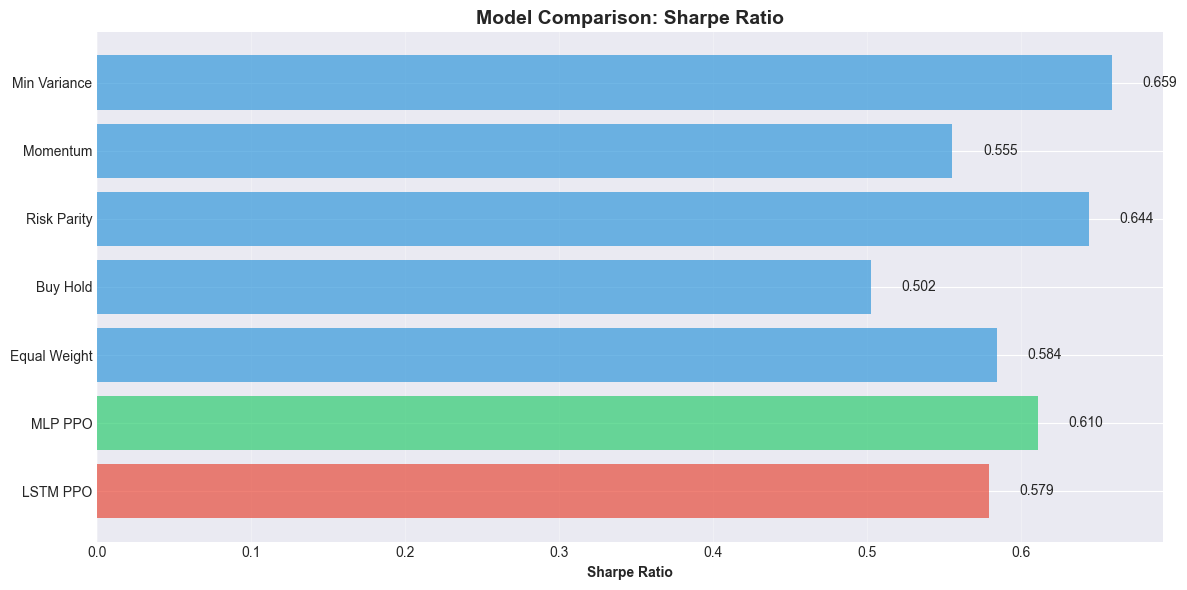


Saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/lstm_comparison.png


In [9]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

models = list(comparison_data.keys())
sharpes = list(comparison_data.values())

# Color based on model type
colors = []
for m in models:
    if 'LSTM' in m:
        colors.append('#e74c3c')  # Red for LSTM
    elif 'PPO' in m or 'MLP' in m:
        colors.append('#2ecc71')  # Green for MLP PPO
    else:
        colors.append('#3498db')  # Blue for baselines

bars = ax.barh(models, sharpes, color=colors, alpha=0.7)
ax.set_xlabel('Sharpe Ratio', fontweight='bold')
ax.set_title('Model Comparison: Sharpe Ratio', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, sharpes):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()

# Save
plot_path = OUTPUT_DIR / 'lstm_comparison.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: {plot_path}")

## 7. Analyze LSTM Learning

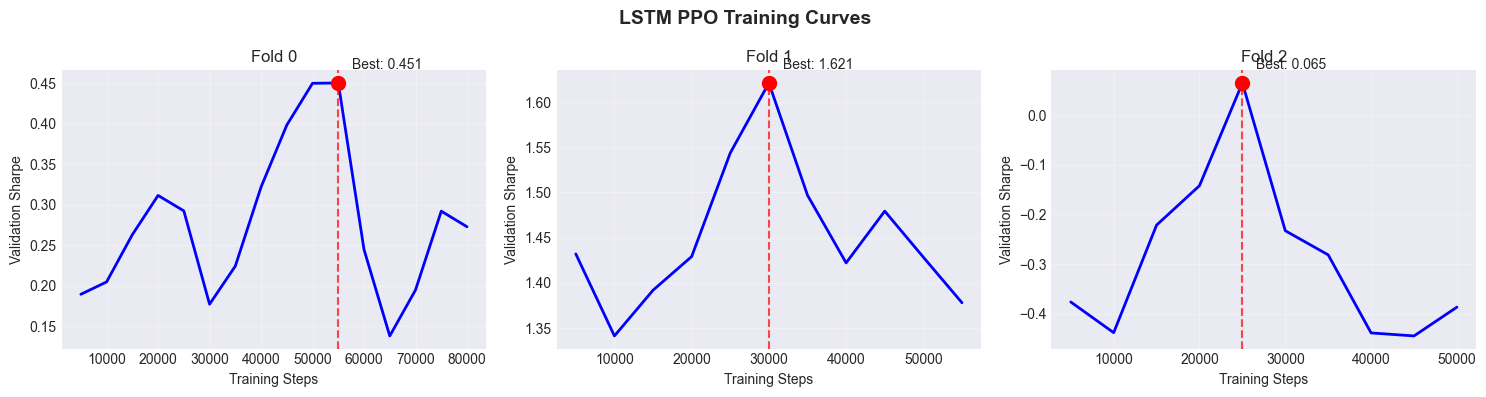

In [10]:
# Plot training curves for LSTM
fig, axes = plt.subplots(1, N_FOLDS, figsize=(5*N_FOLDS, 4))
if N_FOLDS == 1:
    axes = [axes]

for fold_idx in range(N_FOLDS):
    val_log_path = OUTPUT_DIR / 'lstm_ppo' / f'fold_{fold_idx}' / 'logs' / 'val_evaluations.csv'
    
    if val_log_path.exists():
        val_df = pd.read_csv(val_log_path)
        
        ax = axes[fold_idx]
        ax.plot(val_df['step'], val_df['sharpe_ratio'], 'b-', linewidth=2)
        ax.set_xlabel('Training Steps')
        ax.set_ylabel('Validation Sharpe')
        ax.set_title(f'Fold {fold_idx}')
        ax.grid(True, alpha=0.3)
        
        # Mark best
        best_idx = val_df['sharpe_ratio'].idxmax()
        best_step = val_df.loc[best_idx, 'step']
        best_sharpe = val_df.loc[best_idx, 'sharpe_ratio']
        ax.axvline(x=best_step, color='r', linestyle='--', alpha=0.7)
        ax.scatter([best_step], [best_sharpe], color='r', s=100, zorder=5)
        ax.annotate(f'Best: {best_sharpe:.3f}', 
                   xy=(best_step, best_sharpe),
                   xytext=(10, 10), textcoords='offset points')
    else:
        print(f"No validation log found for fold {fold_idx}")

plt.suptitle('LSTM PPO Training Curves', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Summary

In [11]:
print(f"{'='*80}")
print("LSTM PPO TRAINING COMPLETE")
print(f"{'='*80}\n")

print(f"LSTM PPO Model:")
print(f"  Mean Sharpe: {lstm_df['sharpe_ratio'].mean():.3f} +/- {lstm_df['sharpe_ratio'].std():.3f}")
print(f"  Mean Return: {lstm_df['total_return'].mean():.2%}")
print(f"  Model path: {OUTPUT_DIR / 'lstm_ppo'}")

print(f"\nArchitecture:")
print(f"  LSTM hidden size: {LSTM_HIDDEN_SIZE}")
print(f"  LSTM layers: {N_LSTM_LAYERS}")
print(f"  Shared actor/critic: {SHARED_LSTM}")

print(f"\nOutput files:")
print(f"  - lstm_ppo_results.csv")
print(f"  - lstm_comparison.png")
print(f"  - lstm_ppo/fold_*/best_model.zip")

print(f"\nNext steps:")
print(f"  1. Run backtests on test set")
print(f"  2. Compare LSTM vs MLP in detail")
print(f"  3. Tune LSTM hyperparameters if needed")

LSTM PPO TRAINING COMPLETE

LSTM PPO Model:
  Mean Sharpe: 0.579 +/- 0.866
  Mean Return: 68.20%
  Model path: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/lstm_ppo

Architecture:
  LSTM hidden size: 100
  LSTM layers: 1
  Shared actor/critic: True

Output files:
  - lstm_ppo_results.csv
  - lstm_comparison.png
  - lstm_ppo/fold_*/best_model.zip

Next steps:
  1. Run backtests on test set
  2. Compare LSTM vs MLP in detail
  3. Tune LSTM hyperparameters if needed


## Notes

**LSTM PPO Benefits:**
- Captures temporal dependencies in features
- Hidden state carries market regime information
- Better for sequential decision making

**Hyperparameter Tuning:**
- `lstm_hidden_size`: Try 64, 128, 256
- `n_lstm_layers`: Usually 1-2 is enough
- `n_steps`: Shorter sequences (64-256) work better for LSTM

**If performance is worse:**
- Reduce learning rate further
- Increase LSTM hidden size
- Add more training timesteps
- Check for vanishing gradients (use gradient clipping)